In [3]:
import numpy as np
import open3d as o3d
import torch
import matplotlib.pyplot as plt

# Read .ply file
input_file = "../../experiments/test/ply/22.ply"
input_file_seen = "../../experiments/test/ply_seen/22_seen.ply"
pcd = o3d.io.read_point_cloud(input_file) # Read the point cloud
pcd_seen = o3d.io.read_point_cloud(input_file_seen) # Read the point cloud

# Convert open3d format to numpy array
# Here, you have the point cloud in numpy format. 
pc = np.asarray(pcd.points) 
pc_seen = np.asarray(pcd_seen.points)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [93]:
def project_pc(pred_points, pred_rgb):
    # pred
    points = pred_points
    features = pred_rgb
    good_points = points[:, 0] != -100

    if good_points.sum() != 0:
        # filter out ceiling and floor
        mask = (points[:, 1] > - 3.5) & (points[:, 1] < -0.2)
        points = points[mask]
        features = features[mask]

    # project to 2D
    points_2d = points.copy()
    points_2d[:, 1] = 1.0

    # plot top-down view
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.set_aspect('equal')
    ax.set_xlim(-4.1, 4.1)
    ax.set_ylim(-0.1, 8.1)
    ax.scatter(points_2d[:, 0], points_2d[:, 2], c = features, s = 10, marker = 's', cmap='viridis')
    plt.show()


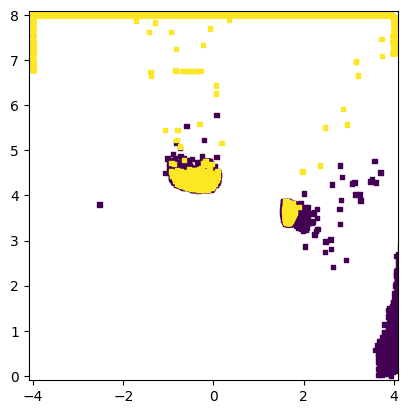

In [95]:
# camPos = np.array([0.1, 0.1, 0.485]) # forward, left, up
camPos = np.array([-0.1, -0.485, 0.1]) # right, down, forward
pc_all = np.concatenate((pc, pc_seen), axis=0)
pc_all = pc_all + camPos

feature_seen = np.ones(pc_seen.shape[0])
feature_pred = np.zeros(pc.shape[0])
feature_all = np.concatenate((feature_pred, feature_seen), axis=0)


project_pc(pc_all, feature_all)

In [85]:
feature_pred

array([0.9, 0.9, 0.9, ..., 0.9, 0.9, 0.9])